In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

%matplotlib inline

In [2]:
df = pd.read_csv('https://raw.githubusercontent.com/alexeygrigorev/datasets/master/car_fuel_efficiency.csv')

In [3]:
df.head()

,engine_displacement,num_cylinders,horsepower,vehicle_weight,acceleration,model_year,origin,fuel_type,drivetrain,num_doors,fuel_efficiency_mpg
0,170,3.0,159.0,3413.433759,17.7,2003,Europe,Gasoline,All-wheel drive,0.0,13.231729
1,130,5.0,97.0,3149.664934,17.8,2007,USA,Gasoline,Front-wheel drive,0.0,13.688217
2,170,NaN,78.0,3079.038997,15.1,2018,Europe,Gasoline,Front-wheel drive,0.0,14.246341
3,220,4.0,NaN,2542.392402,20.2,2009,USA,Diesel,All-wheel drive,2.0,16.912736
4,210,1.0,140.0,3460.870990,14.4,2009,Europe,Gasoline,All-wheel drive,2.0,12.488369


In [4]:
df1 = df[['engine_displacement', 'horsepower', 'vehicle_weight', 'model_year', 'fuel_efficiency_mpg']]


In [5]:
df1

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,170,159.0,3413.433759,2003,13.231729
1,130,97.0,3149.664934,2007,13.688217
2,170,78.0,3079.038997,2018,14.246341
3,220,NaN,2542.392402,2009,16.912736
4,210,140.0,3460.870990,2009,12.488369
...,...,...,...,...,...
9699,140,164.0,2981.107371,2013,15.101802
9700,180,154.0,2439.525729,2004,17.962326
9701,220,138.0,2583.471318,2008,17.186587
9702,230,177.0,2905.527390,2011,15.331551


In [6]:
df2 = df1.copy()
df3 = df1.copy()
df4 = df1.copy()
df5 = df1.copy()
df6 = df1.copy()

In [7]:
df2

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,170,159.0,3413.433759,2003,13.231729
1,130,97.0,3149.664934,2007,13.688217
2,170,78.0,3079.038997,2018,14.246341
3,220,NaN,2542.392402,2009,16.912736
4,210,140.0,3460.870990,2009,12.488369
...,...,...,...,...,...
9699,140,164.0,2981.107371,2013,15.101802
9700,180,154.0,2439.525729,2004,17.962326
9701,220,138.0,2583.471318,2008,17.186587
9702,230,177.0,2905.527390,2011,15.331551


-----------------------------------------------------------------------------------------------------------------------------

In [8]:
columns_with_nan = df1.isna().any()
print("Columns with at least one NaN value:\n", columns_with_nan)

Columns with at least one NaN value:
 engine_displacement    False
horsepower              True
vehicle_weight         False
model_year             False
fuel_efficiency_mpg    False
dtype: bool


### Q1 Horsepower is the column with missing values

In [9]:
median_horsepower = df1['horsepower'].median()

In [10]:
print(f"Median of 'horsepower': {median_horsepower}")

Median of 'horsepower': 149.0


### Q2 Median of horsepower column is 149

In [11]:
df1.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9704 entries, 0 to 9703
Data columns (total 5 columns):
 #   Column               Non-Null Count  Dtype  
---  ------               --------------  -----  
 0   engine_displacement  9704 non-null   int64  
 1   horsepower           8996 non-null   float64
 2   vehicle_weight       9704 non-null   float64
 3   model_year           9704 non-null   int64  
 4   fuel_efficiency_mpg  9704 non-null   float64
dtypes: float64(3), int64(2)
memory usage: 379.2 KB


-----------------------------------------------------------------------------------------------------------------------

In [12]:
np.random.seed(42)

n = len(df1)

n_val = int(0.2 * n)
n_test = int(0.2 * n)
n_train = n - (n_val + n_test)

idx = np.arange(n)
np.random.shuffle(idx)

df_shuffled = df1.iloc[idx]

df_train = df_shuffled.iloc[:n_train].copy()
df_val = df_shuffled.iloc[n_train:n_train+n_val].copy()
df_test = df_shuffled.iloc[n_train+n_val:].copy()

In [13]:
y_train_orig = df_train.fuel_efficiency_mpg.values
y_val_orig = df_val.fuel_efficiency_mpg.values
y_test_orig = df_test.fuel_efficiency_mpg.values

y_train = np.log1p(df_train.fuel_efficiency_mpg.values)
y_val = np.log1p(df_val.fuel_efficiency_mpg.values)
y_test = np.log1p(df_test.fuel_efficiency_mpg.values)

del df_train['fuel_efficiency_mpg']
del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

#### Linear Regression

In [14]:
def train_linear_regression(X, y):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)
    
    return w[0], w[1:]

#### Baseline solution

In [15]:
base = ['horsepower']


In [16]:
def prepare_X(df):
    df_num = df[base]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [17]:
X_train = prepare_X(df_train)
w_0, w = train_linear_regression(X_train, y_train)

In [18]:
y_pred = w_0 + X_train.dot(w)

Text(0.5, 1.0, 'Predictions vs actual distribution')

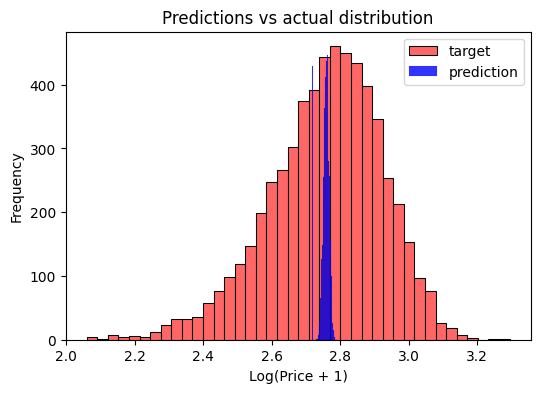

In [19]:
plt.figure(figsize=(6, 4))

sns.histplot(y_train, label='target', color='red', alpha=0.6, bins=40)
sns.histplot(y_pred, label='prediction', color='blue', alpha=0.8, bins=40)

plt.legend()

plt.ylabel('Frequency')
plt.xlabel('Log(Price + 1)')
plt.title('Predictions vs actual distribution')


In [20]:
def rmse(y, y_pred):
    error = y_pred - y
    mse = (error ** 2).mean()
    return np.sqrt(mse)

In [21]:
rmse(y_train, y_pred)


np.float64(0.165680788132653)

----------------------------------------------------------------------------------------------------------------------------

In [22]:
np.random.seed(42)

n = len(df2)

n_val2 = int(0.2 * n)
n_test2 = int(0.2 * n)
n_train2= n - (n_val2 + n_test2)

idx = np.arange(n)
np.random.shuffle(idx)

df_shuffled2 = df2.iloc[idx]

df_train2 = df_shuffled2.iloc[:n_train2].copy()
df_val2 = df_shuffled2.iloc[n_train2:n_train2+n_val2].copy()
df_test2 = df_shuffled2.iloc[n_train2+n_val2:].copy()

In [23]:
y_train_orig2 = df_train2.fuel_efficiency_mpg.values
y_val_orig2 = df_val2.fuel_efficiency_mpg.values
y_test_orig2 = df_test2.fuel_efficiency_mpg.values

y_train2 = np.log1p(df_train2.fuel_efficiency_mpg.values)
y_val2 = np.log1p(df_val2.fuel_efficiency_mpg.values)
y_test2= np.log1p(df_test2.fuel_efficiency_mpg.values)

del df_train2['fuel_efficiency_mpg']
del df_val2['fuel_efficiency_mpg']
del df_test2['fuel_efficiency_mpg']

In [24]:
def prepare_X1(df):
    df_num = df[base]
    df_num = df_num.fillna(149)
    X = df_num.values
    return X

In [25]:
X_train2 = prepare_X1(df_train2)
w_0, w = train_linear_regression(X_train2, y_train2)

In [26]:
y_pred2 = w_0 + X_train2.dot(w)

Text(0.5, 1.0, 'Predictions vs actual distribution')

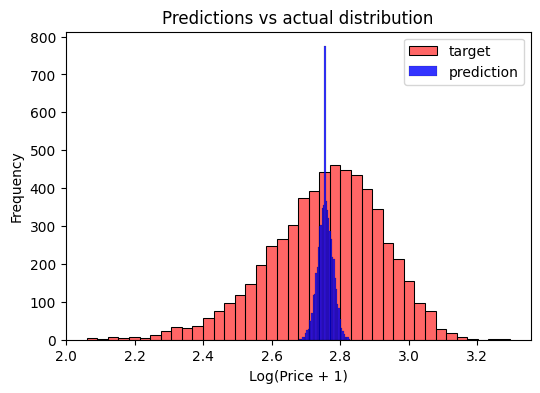

In [27]:
plt.figure(figsize=(6, 4))

sns.histplot(y_train2, label='target', color='red', alpha=0.6, bins=40)
sns.histplot(y_pred2, label='prediction', color='blue', alpha=0.8, bins=40)

plt.legend()

plt.ylabel('Frequency')
plt.xlabel('Log(Price + 1)')
plt.title('Predictions vs actual distribution')


In [28]:
def rmse(y, y_pred):
    error = y_pred - y
    mse = (error ** 2).mean()
    return np.sqrt(mse)

In [29]:
rmse(y_train2, y_pred2)


np.float64(0.16483340075743616)

### Q3 WITH MEAN 

-------------------------------------------------------------------------------------------------------------------------

In [30]:
df3

,engine_displacement,horsepower,vehicle_weight,model_year,fuel_efficiency_mpg
0,170,159.0,3413.433759,2003,13.231729
1,130,97.0,3149.664934,2007,13.688217
2,170,78.0,3079.038997,2018,14.246341
3,220,NaN,2542.392402,2009,16.912736
4,210,140.0,3460.870990,2009,12.488369
...,...,...,...,...,...
9699,140,164.0,2981.107371,2013,15.101802
9700,180,154.0,2439.525729,2004,17.962326
9701,220,138.0,2583.471318,2008,17.186587
9702,230,177.0,2905.527390,2011,15.331551


#### Regularization

In [31]:
def prepare_X(df):
    df_num = df[base]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [32]:
def train_linear_regression_reg(X, y, r=0.0):
    ones = np.ones(X.shape[0])
    X = np.column_stack([ones, X])

    XTX = X.T.dot(X)
    reg = r * np.eye(XTX.shape[0])
    XTX = XTX + reg

    XTX_inv = np.linalg.inv(XTX)
    w = XTX_inv.dot(X.T).dot(y)
    
    return w[0], w[1:]

In [33]:
np.random.seed(42)

n = len(df3)

n_val3 = int(0.2 * n)
n_test3 = int(0.2 * n)
n_train3= n - (n_val3 + n_test3)

idx = np.arange(n)
np.random.shuffle(idx)

df_shuffled3 = df3.iloc[idx]

df_train3 = df_shuffled3.iloc[:n_train3].copy()
df_val3 = df_shuffled3.iloc[n_train3:n_train3+n_val3].copy()
df_test3 = df_shuffled3.iloc[n_train3+n_val3:].copy()

In [34]:
y_train_orig3 = df_train3.fuel_efficiency_mpg.values
y_val_orig3 = df_val3.fuel_efficiency_mpg.values
y_test_orig3 = df_test3.fuel_efficiency_mpg.values

y_train3 = np.log1p(df_train3.fuel_efficiency_mpg.values)
y_val3 = np.log1p(df_val3.fuel_efficiency_mpg.values)
y_test3= np.log1p(df_test3.fuel_efficiency_mpg.values)

del df_train3['fuel_efficiency_mpg']
del df_val3['fuel_efficiency_mpg']
del df_test3['fuel_efficiency_mpg']

In [36]:
X_train3 = prepare_X1(df_train3)
w_0, w = train_linear_regression(X_train3, y_train3)

In [29]:
X_train = prepare_X(df_train)

In [30]:
for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    w_0, w = train_linear_regression_reg(X_train, y_train, r=r)
    y_pred = w_0 + X_train.dot(w)
    rmse(y_train, y_pred)
    print(r, rmse(y_train, y_pred))
    #print('%5s, %.2f, %.2f, %.2f' % (r, w_0, w[0], w[0]))

0 0.165680788132653
0.01 0.1656807887379454
0.1 0.1656808486446616
1 0.1656868220425837
5 0.16582968455330918
10 0.166266368315576
100 0.2059246533483141


In [31]:
X_train = prepare_X(df_train)
w_0, w = train_linear_regression_reg(X_train, y_train, r=0)

y_pred = w_0 + X_train.dot(w)
print('train', rmse(y_train, y_pred))

X_val = prepare_X(df_val)
y_pred = w_0 + X_val.dot(w)
print('val', rmse(y_val, y_pred))

train 0.165680788132653
val 0.17140940715265338


In [32]:
X_train = prepare_X(df_train)
w_0, w = train_linear_regression_reg(X_train, y_train, r=0.01)

y_pred = w_0 + X_train.dot(w)
print('train', rmse(y_train, y_pred))

X_val = prepare_X(df_val)
y_pred = w_0 + X_val.dot(w)
print('val', rmse(y_val, y_pred))

train 0.1656807887379454
val 0.17140954005753498


In [33]:
X_train = prepare_X(df_train)
X_val = prepare_X(df_val)

for r in [0, 0.01, 0.1, 1, 5, 10, 100]:
    w_0, w = train_linear_regression_reg(X_train, y_train, r=r)
    y_pred = w_0 + X_val.dot(w)
    print('%6s' %r, rmse(y_val, y_pred))

     0 0.17140940715265338
  0.01 0.17140954005753498
   0.1 0.17141078864892173
     1 0.17142844995112597
     5 0.17161891076003766
    10 0.17210528554094515
   100 0.21149044455218755


In [34]:
X_train = prepare_X(df_train)
w_0, w = train_linear_regression_reg(X_train, y_train, r=0.01)

X_val = prepare_X(df_val)
y_pred = w_0 + X_val.dot(w)
print('validation:', rmse(y_val, y_pred))

X_test = prepare_X(df_test)
y_pred = w_0 + X_test.dot(w)
print('test:', rmse(y_test, y_pred))

validation: 0.17140954005753498
test: 0.1579488049896752


### Q4 WITH 0.01

-----------------------------------------------------------------------------------------------------------------------------

https://stats.stackexchange.com/questions/629452/accuracy-score-change-a-lot-by-changing-random-seed-in-train-test-split

In [33]:
result_rmse = []
for i in range(10):

    # Set a new seed
    # 
    np.random.seed(i)
    n3 = len(df3)
    
    n_val3 = int(0.2 * n3)
    n_test3 = int(0.2 * n3)
    n_train3 = n - (n_val3 + n_test3)
    
    idx = np.arange(n3)
    np.random.shuffle(idx)
    
    df_shuffled3 = df3.iloc[idx]
    
    df_train3 = df_shuffled3.iloc[:n_train3].copy()
    df_val3 = df_shuffled3.iloc[n_train3:n_train3+n_val3].copy()
    df_test3 = df_shuffled3.iloc[n_train3+n_val3:].copy()

    
    y_train_orig3 = df_train3.fuel_efficiency_mpg.values
    y_val_orig3 = df_val3.fuel_efficiency_mpg.values
    y_test_orig3 = df_test3.fuel_efficiency_mpg.values
    
    y_train3 = np.log1p(df_train3.fuel_efficiency_mpg.values)
    y_val3 = np.log1p(df_val3.fuel_efficiency_mpg.values)
    y_test3 = np.log1p(df_test3.fuel_efficiency_mpg.values)
    
    del df_train3['fuel_efficiency_mpg']
    del df_val3['fuel_efficiency_mpg']
    del df_test3['fuel_efficiency_mpg']
    # Run the rest of your code to split the data, train the model, 
    # and report the performance for seed i

    X_train = prepare_X(df_train3)
    w_0, w = train_linear_regression(X_train3, y_train3)

    y_pred = w_0 + X_train.dot(w)

    result_rmse.append((rmse(y_train3, y_pred3)))
    

In [34]:
result_rmse

[np.float64(0.16551455554292807),
 np.float64(0.16581176154012356),
 np.float64(0.16601470526262785),
 np.float64(0.1655423405377475),
 np.float64(0.1651659391254374),
 np.float64(0.16601734934196222),
 np.float64(0.16546850658978127),
 np.float64(0.165981786339233),
 np.float64(0.16603892485759378),
 np.float64(0.16602034309370295)]

In [35]:
std_rmse = np.std(result_rmse)

In [36]:
std_rmse

np.float64(0.0002956329248671819)

### Question 6

In [39]:
np.random.seed(9)

n = len(df2)

#n_val = int(0.2 * n)
n_test = int(0.2 * n)
n_train = n - (n_val + n_test)

idx = np.arange(n)
np.random.shuffle(idx)

df_shuffled = df.iloc[idx]

df_train = df_shuffled.iloc[:n_train].copy()
#df_val = df_shuffled.iloc[n_train:n_train+n_val].copy()
df_test = df_shuffled.iloc[n_train+n_val:].copy()

In [40]:
y_train_orig = df_train.fuel_efficiency_mpg.values
#y_val_orig = df_val.fuel_efficiency_mpg.values
y_test_orig = df_test.fuel_efficiency_mpg.values

y_train = np.log1p(df_train.fuel_efficiency_mpg.values)
#y_val = np.log1p(df_val.fuel_efficiency_mpg.values)
y_test = np.log1p(df_test.fuel_efficiency_mpg.values)

del df_train['fuel_efficiency_mpg']
#del df_val['fuel_efficiency_mpg']
del df_test['fuel_efficiency_mpg']

In [41]:
base = ['horsepower']

In [42]:
def prepare_X(df):
    df_num = df[base]
    df_num = df_num.fillna(0)
    X = df_num.values
    return X

In [43]:
X_train = prepare_X(df_train)
w_0, w = train_linear_regression_reg(X_train, y_train, r=0.001)

In [44]:
y_pred = w_0 + X_train.dot(w)


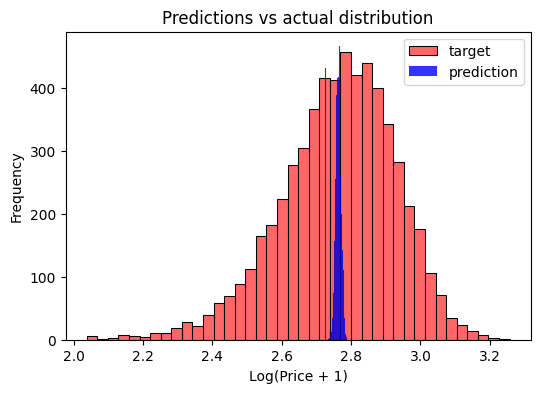

In [45]:
plt.figure(figsize=(6, 4))

sns.histplot(y_train, label='target', color='red', alpha=0.6, bins=40)
sns.histplot(y_pred, label='prediction', color='blue', alpha=0.8, bins=40)

plt.legend()

plt.ylabel('Frequency')
plt.xlabel('Log(Price + 1)')
plt.title('Predictions vs actual distribution')

plt.show()

In [46]:
rmse(y_train, y_pred)

np.float64(0.1660203430996986)